In [4]:
import os
from pathlib import Path
import sys
import numpy as np
import scvelo as scv

In [5]:
notebook_dir = os.getcwd()
notebook_dir

'c:\\Users\\OmerCagatayTalikaci\\Desktop\\github\\STVelo\\notebooks\\analysis\\final'

In [6]:
Path(notebook_dir).parents[3]

WindowsPath('c:/Users/OmerCagatayTalikaci/Desktop/github')

In [7]:
os.chdir(Path(notebook_dir).parents[3])

In [8]:
stvelo_path = os.path.join(os.getcwd(),'STVelo','stvelo')

import sys  
sys.path.insert(1,stvelo_path)

from pipelines.metrics import *
from pipelines.utils import proportions_nuc_cyto

# Read adatas 

In [9]:
adata_folder_path = os.path.join(os.getcwd(), 'data', '01_comp1') 

In [10]:
import os
import anndata as ad


# Initialize an empty dictionary to store the AnnData objects
adata_dict = {}

# Loop through all files in the folder
for file_name in os.listdir(adata_folder_path):
    # Check if the file has .h5ad extension
    if file_name.endswith('.h5ad'):
        # Remove the file extension to use as the dictionary key
        key = os.path.splitext(file_name)[0]
        
        # Read the .h5ad file and store it in the dictionary
        adata_dict[key] = scv.read(os.path.join(adata_folder_path, file_name))

# Now, adata_dict contains the .h5ad files with keys as their filenames without extension


In [11]:
adatas = {k:v.copy() for k,v in adata_dict.items()}

In [12]:
adatas.keys()

dict_keys(['adata_n_c_1000obs_400genes_deterministic', 'adata_n_c_1000obs_400genes_dynamical', 'adata_n_c_1000obs_400genes_stochastic', 'adata_n_c_1000obs_400genes_velovi', 'adata_s_u_1000obs_400genes_deterministic', 'adata_s_u_1000obs_400genes_dynamical', 'adata_s_u_1000obs_400genes_stochastic', 'adata_s_u_1000obs_400genes_velovi'])

In [13]:
deterministic_dict = {k: v.copy() for k, v in adatas.items() if k.endswith('deterministic')}
dynamical_dict = {k: v.copy() for k, v in adatas.items() if k.endswith('dynamical')}
velovi_dict = {k: v.copy() for k, v in adatas.items() if k.endswith('velovi')}
stochastic_dict = {k: v.copy() for k, v in adatas.items() if k.endswith('stochastic')}

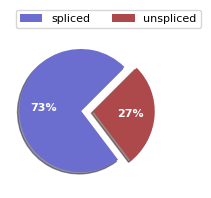

<Axes: >

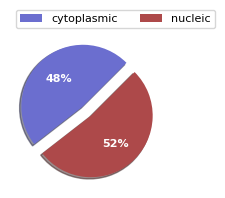

In [14]:
scv.pl.proportions(deterministic_dict['adata_s_u_1000obs_400genes_deterministic'])
proportions_nuc_cyto(adata_dict['adata_n_c_1000obs_400genes_deterministic'])

# Umaps 

In [15]:
import matplotlib.pyplot as plt 

In [16]:
import matplotlib.pyplot as plt
import scvelo as scv

def plot_velocity_embedding_streams(adata_dict, n_obs=1000, n_var=400, color_option='true_t'):
    """
    Plots velocity embedding streams for an AnnData dictionary with a specified color option.

    Parameters:
    - adata_dict (dict): Dictionary with AnnData objects. Keys should follow the pattern 
                         'adata_s_u_800obs_300genes_{velocity_type}' and 
                         'adata_n_c_800obs_300genes_{velocity_type}'.
    - color_option (str): Column name in AnnData.obs to color the plots. Default is 'true_t'.
    """
    # Create a figure with 2 rows and 4 columns of subplots
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))  # Adjust figsize for better visibility

    # List of velocity types and corresponding column labels
    velocity_types = ['deterministic', 'stochastic', 'dynamical', 'velovi']
    column_labels = ['Deterministic', 'Stochastic', 'Dynamical', 'VeloVI']

    # Row titles
    row_titles = ['Unspliced - Spliced', 'Cytoplasmic - Nucleic']

    # Adjust subplot parameters to make room for column headings
    plt.subplots_adjust(top=0.90, left=0.10)

    # Loop over each data type and plot the corresponding subplots
    for i, (data_type, row_title) in enumerate(zip(['s_u', 'n_c'], row_titles)):
        for j, (velocity_type, col_label) in enumerate(zip(velocity_types, column_labels)):
            # Plotting
            adata_key = f'adata_{data_type}_{n_obs}obs_{n_var}genes_{velocity_type}'
            if adata_key in adata_dict:
                scv.pl.velocity_embedding_stream(
                    adata_dict[adata_key],
                    basis='umap',
                    color=color_option,
                    ax=axes[i, j],
                    show=False,
                    title=''
                )
            else:
                axes[i, j].axis('off')  # If the adata is not available, turn off the axis

            # Turn off axis labels to reduce clutter
            axes[i, j].set_xlabel('')
            axes[i, j].set_ylabel('')

    # Add column titles (velocity models)
    for j, col_label in enumerate(column_labels):
        axes[0, j].set_title(col_label, fontsize=16)

    # Add row titles (data types)
    for i, row_title in enumerate(row_titles):
        # Place text in the middle of the row
        fig.text(
            0.04,  # Adjust as needed for horizontal position
            (0.72 - i * 0.44),  # Adjust for vertical position
            row_title,
            ha='center',
            va='center',
            rotation='vertical',
            fontsize=16
        )

    # Adjust layout to prevent overlap
    plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])

    # Show the plot
    plt.show()


In [26]:
adata_dict['adata_n_c_1000obs_400genes_dynamical'].var['fit_t_']

0       8.745476
1      12.392275
2      10.354718
3      11.930877
4      10.635635
         ...    
395    15.280672
396    11.195990
397     9.902706
398     6.694100
399     7.764987
Name: fit_t_, Length: 400, dtype: float64

In [27]:
adata_dict['adata_n_c_1000obs_400genes_velovi'].var['fit_t_']

0      10.362372
1      11.484349
2      10.499181
3       9.625489
4      11.331488
         ...    
391     9.694357
393    12.409530
395    15.220887
396    12.254099
397     9.167058
Name: fit_t_, Length: 315, dtype: float32

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


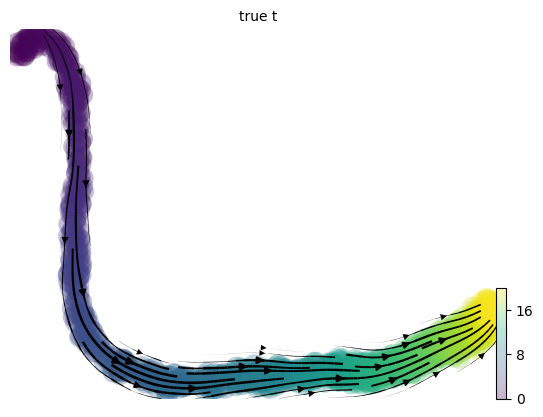

In [15]:
scv.pl.velocity_embedding_stream(adata_dict['adata_n_c_1000obs_400genes_dynamical'],color ='true_t')

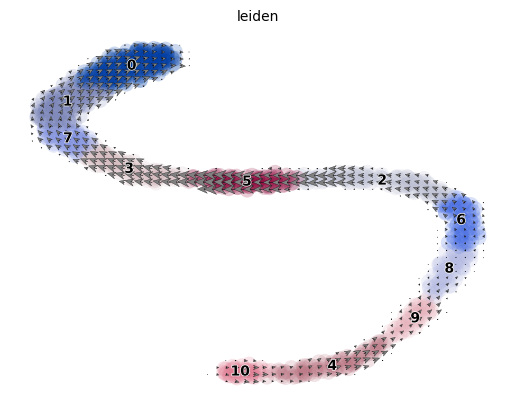

In [79]:
scv.pl.velocity_embedding_grid(adata_dict['adata_n_c_1000obs_400genes_deterministic'],color ='leiden',legend_loc='on data',arrow_size=9, arrow_length=1.2)

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


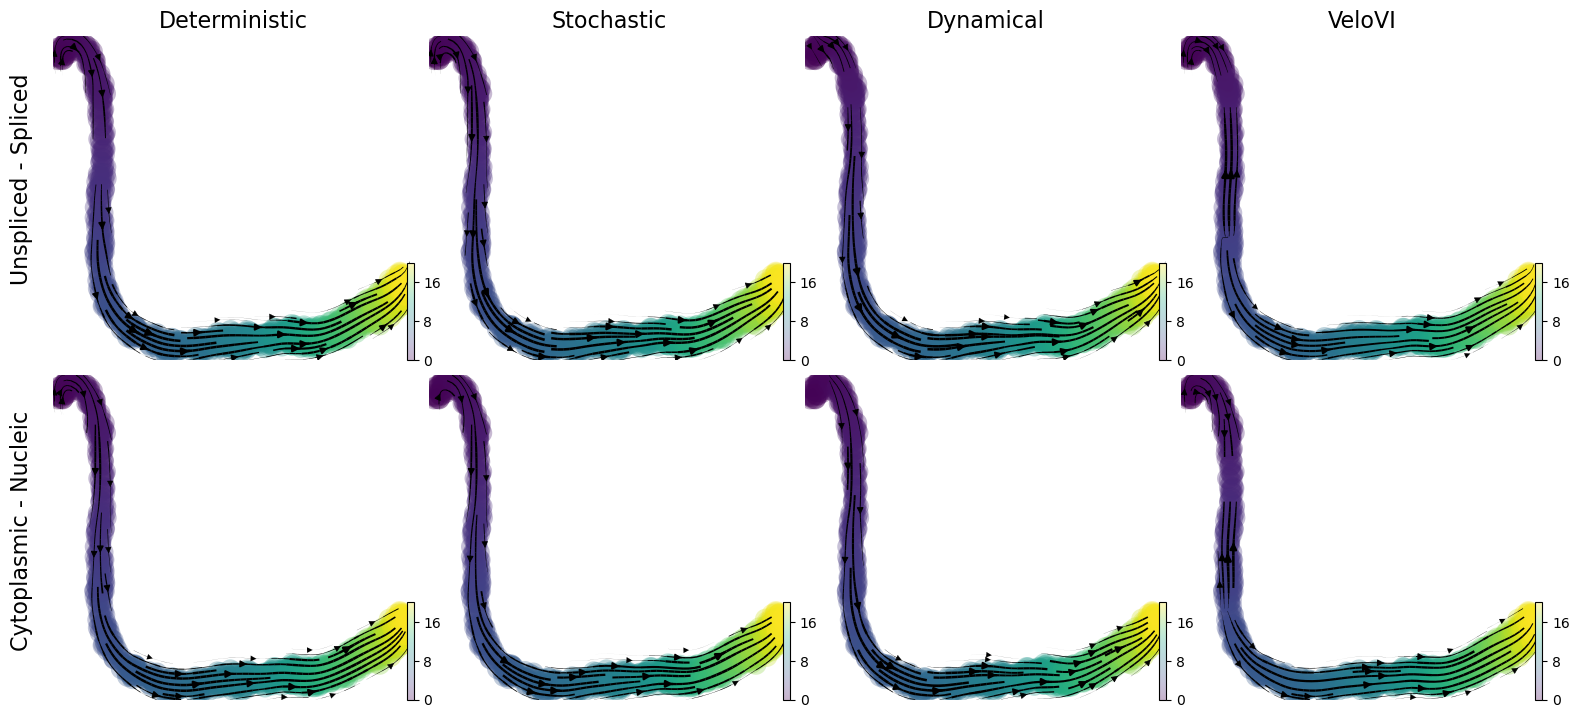

In [16]:
plot_velocity_embedding_streams(adata_dict=adata_dict, color_option='true_t')

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def extract_velocity_gene_counts(adata_dict):
    """
    Extracts the velocity gene counts from each AnnData object in adata_dict.

    Parameters:
    - adata_dict (dict): Dictionary of AnnData objects with keys in the format
                         'adata_dataType_obs_genes_velocityType'

    Returns:
    - DataFrame: A pandas DataFrame containing the velocity gene counts and metadata.
    """

    # Initialize a list to collect data
    data_list = []

    # Loop over each AnnData object in the dictionary
    for key, adata in adata_dict.items():
        # Parse the key to extract metadata
        # Example key: 'adata_n_c_1000obs_400genes_deterministic'
        parts = key.split('_')

        # Extract data type ('n_c' or 's_u')
        data_type = parts[1]  # Assuming 'n_c' or 's_u' is at index 1

        # Extract observation counts (e.g., '1000obs')
        obs_part = parts[3]  # Assuming '1000obs' is at index 2
        obs_count = int(obs_part.replace('obs', ''))

        # Extract gene counts (e.g., '400genes')
        gene_part = parts[4]  # Assuming '400genes' is at index 3
        gene_count = int(gene_part.replace('genes', ''))

        # Extract velocity model type (e.g., 'deterministic', 'stochastic', etc.)
        velocity_model = parts[-1]

        # Count the number of velocity genes
        # adata.var['velocity_genes'] is a boolean series indicating velocity genes
        velocity_genes_series = adata.var['velocity_genes']
        num_velocity_genes = velocity_genes_series.sum()

        # Total number of genes
        total_genes = len(adata.var)

        # Calculate the percentage of velocity genes
        percent_velocity_genes = (num_velocity_genes / 400) * 100

        # Create a dictionary with the collected data
        data_dict = {
            'data_type': 'Nucleic-Cytoplasmic' if data_type == 'n' else 'Spliced-Unspliced',
            'velocity_model': velocity_model.capitalize(),
            'obs_count': obs_count,
            'gene_count': gene_count,
            'num_velocity_genes': num_velocity_genes,
            'total_genes': total_genes,
            'percent_velocity_genes': percent_velocity_genes
        }

        # Append the data to the list
        data_list.append(data_dict)

    # Create a DataFrame from the collected data
    df = pd.DataFrame(data_list)

    return df

# Example usage
# Assuming adata_dict is your dictionary of AnnData objects
df_velocity_genes = extract_velocity_gene_counts(adata_dict)

# Display the DataFrame
print(df_velocity_genes)


             data_type velocity_model  obs_count  gene_count  \
0  Nucleic-Cytoplasmic  Deterministic       1000         400   
1  Nucleic-Cytoplasmic      Dynamical       1000         400   
2  Nucleic-Cytoplasmic     Stochastic       1000         400   
3  Nucleic-Cytoplasmic         Velovi       1000         400   
4    Spliced-Unspliced  Deterministic       1000         400   
5    Spliced-Unspliced      Dynamical       1000         400   
6    Spliced-Unspliced     Stochastic       1000         400   
7    Spliced-Unspliced         Velovi       1000         400   

   num_velocity_genes  total_genes  percent_velocity_genes  
0                 315          400                   78.75  
1                 356          400                   89.00  
2                 315          400                   78.75  
3                 315          315                   78.75  
4                 343          400                   85.75  
5                 397          400                   99.2

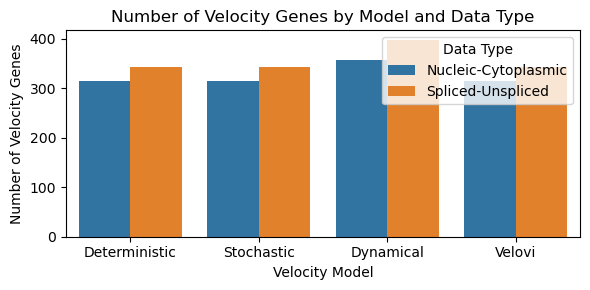

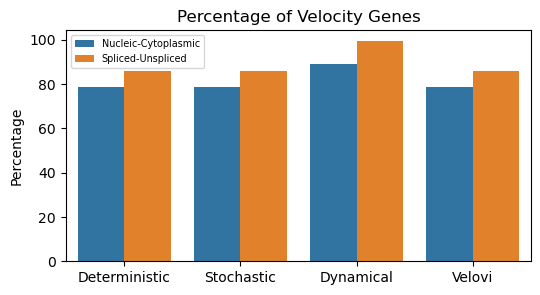

In [18]:
velocity_model_order = ['Deterministic', 'Stochastic', 'Dynamical', 'Velovi']


# Set the aesthetic style of the plots
# sns.set(style="whitegrid")

# Create a bar plot for the number of velocity genes
plt.figure(figsize=(6, 3))
sns.barplot(
    data=df_velocity_genes,
    x='velocity_model',
    y='num_velocity_genes',
    hue='data_type',
    order=velocity_model_order
    # palette='Set2'
)
plt.title('Number of Velocity Genes by Model and Data Type')
plt.xlabel('Velocity Model')
plt.ylabel('Number of Velocity Genes')
plt.legend(title='Data Type')
plt.tight_layout()
plt.show()

# Create a bar plot for the percentage of velocity genes
plt.figure(figsize=(6, 3))
sns.barplot(
    data=df_velocity_genes,
    x='velocity_model',
    y='percent_velocity_genes',
    hue='data_type',
    order=velocity_model_order
    # palette='Set2'
)
plt.title('Percentage of Velocity Genes')
plt.xlabel('')
plt.ylabel('Percentage')
plt.legend(loc='best',fontsize='x-small')
# plt.tight_layout()
plt.show()


# Metrics 

## Velocity Confidence


- Confidence metric measures the mean velocity consistency by calculating the pearson correlation between a cell and its neighbours. Let $v(x_j)$ be the velocity of cell $x_j$. Confidence $c_j$ is given by;

$$c_j = \frac{1}{k} \sum_{x \in \mathit{N_k(x_j)} } corr(v(x_j),v(x))$$

where $\mathit{N_k(x_j)}$ is the k-neighbours of $x_j$ in KNN graph.

In [19]:
import scvelo as scv
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_velocity_confidences(adatas):
    """
    Computes velocity confidences for each AnnData object in the dictionary and plots them using a violin plot.

    Parameters:
    - adatas (dict): Dictionary where keys are in the format 'adata_type_obs_genes_velocitytype', 
                     and values are AnnData objects.

    The keys should follow this format:
    - 'adata_n_c_1000obs_400genes_deterministic' or
      'adata_s_u_1000obs_400genes_deterministic'
    """
    
    # Initialize an empty list to collect data for plotting
    plot_data = []

    # Loop through each AnnData object in the dictionary
    for key, adata in adatas.items():
        # Compute velocity confidence
        scv.tl.velocity_confidence(adata)

        # Extract velocity confidences from adata.obs
        velocity_confidence = adata.obs['velocity_confidence'].values
        velocity_length = adata.obs['velocity_length'].values
        velocity_confidence_transition = adata.obs['velocity_confidence_transition'].values

        # Parse the key to extract metadata
        # Key format: 'adata_n_c_1000obs_400genes_deterministic'
        parts = key.split('_')
        data_type = parts[1] + '_' + parts[2]  # e.g., 'n_c' or 's_u'
        obs_count = parts[3]  # e.g., '800obs'
        gene_count = parts[4]  # e.g., '300genes'
        velocity_type = parts[-1]  # e.g., 'deterministic', 'stochastic', 'dynamical', 'velovi'

        # Map data_type to full names
        data_type_map = {'n_c': 'cytoplasmic-nucleic', 's_u': 'unspliced-spliced'}
        data_type_full = data_type_map.get(data_type, data_type)

        # Map velocity_type to capitalized labels
        velocity_type_map = {
            'deterministic': 'Deterministic',
            'stochastic': 'Stochastic',
            'dynamical': 'Dynamical',
            'velovi': 'VeloVI'
        }
        velocity_type_label = velocity_type_map.get(velocity_type, velocity_type.capitalize())

        # Create a DataFrame for this adata
        df = pd.DataFrame({
            'velocity_confidence': velocity_confidence,
            'velocity_length': velocity_length,
            'velocity_confidence_transition': velocity_confidence_transition,
            'data_type': data_type_full,
            'obs_count': obs_count,
            'gene_count': gene_count,
            'velocity_type': velocity_type,
            'velocity_type_label': velocity_type_label
        })

        # Append to the list
        plot_data.append(df)

    # Concatenate all DataFrames into one
    plot_df = pd.concat(plot_data, ignore_index=True)

    # Define the order of velocity types
    velocity_type_order = ['deterministic', 'stochastic', 'dynamical', 'velovi']
    # Corresponding labels
    velocity_type_labels = ['Deterministic', 'Stochastic', 'Dynamical', 'VeloVI']
    # Map velocity_type to labels
    velocity_type_label_map = dict(zip(velocity_type_order, velocity_type_labels))

    # Map velocity_type to categorical type with specified order
    plot_df['velocity_type'] = pd.Categorical(
        plot_df['velocity_type'],
        categories=velocity_type_order,
        ordered=True
    )
    # Ensure the labels are in the same order
    plot_df['velocity_type_label'] = pd.Categorical(
        plot_df['velocity_type_label'],
        categories=velocity_type_labels,
        ordered=True
    )

    # Now, plot using seaborn
    # sns.set(style="whitegrid")

    # Create a color palette for data types
    data_types = plot_df['data_type'].unique()
    # Specify colors you want to use
    custom_palette = ['#1f77b4', '#ff7f0e']  # Example colors: blue and orange
    palette_dict = dict(zip(data_types, custom_palette))

    # Plot the violin plot
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.violinplot(
        x='velocity_type_label', 
        y='velocity_confidence', 
        hue='data_type', 
        data=plot_df, 
        palette=palette_dict, 
        split=False,
        # scale='width',
        # inner='quartile',
        order=velocity_type_labels,
        ax=ax
    )

    # Add vertical lines to separate velocity types
    x_positions = ax.get_xticks()
    for x in x_positions[1:]:
        ax.axvline(x=x - 0.5, color='gray', linestyle='--', linewidth=1)

    # Adjust legend labels
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=labels, title='Data Type', bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=12)

    plt.title('Velocity Consistency by RNA Velocity Model', fontsize=15)
    plt.xlabel('')
    plt.ylabel('Velocity Confidence',fontsize=15)
    plt.tight_layout()
    plt.show()


--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length'

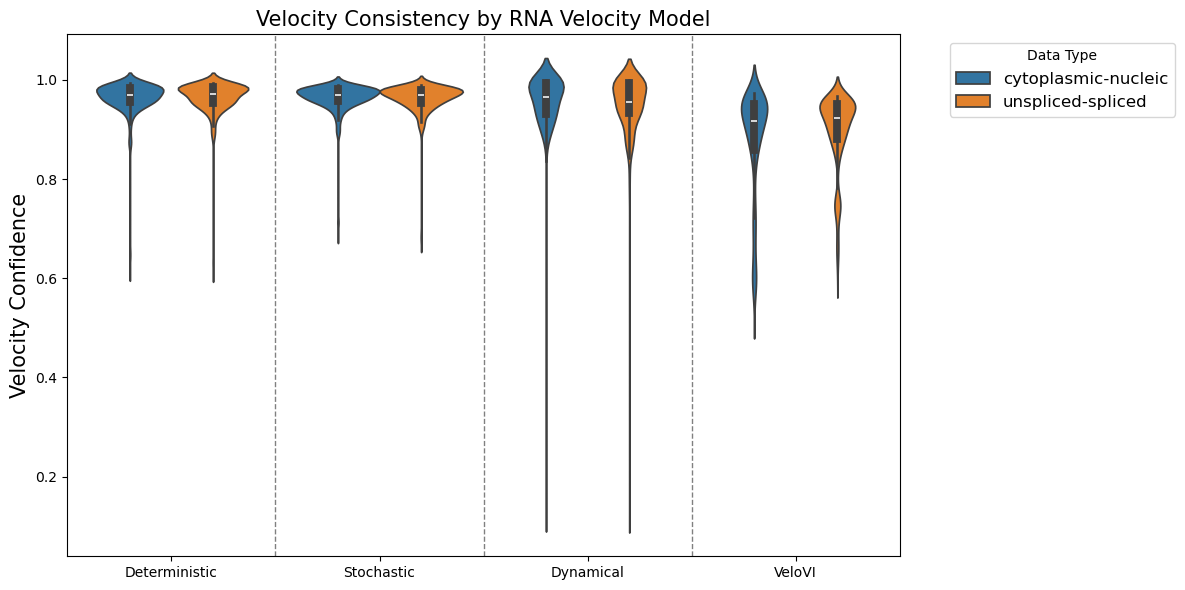

In [20]:
plot_velocity_confidences(adata_dict)

In [38]:
adata_dict['adata_n_c_1000obs_400genes_dynamical'].var

,true_t_,true_alpha,true_beta,true_nu,true_gamma,true_scaling,fit_r2,fit_alpha,fit_beta,fit_gamma,...,fit_std_s,fit_likelihood,fit_u0,fit_s0,fit_pval_steady,fit_steady_u,fit_steady_s,fit_variance,fit_alignment_scaling,velocity_genes
0,8.579455,10.884522,1.620168,1.159402,0.395451,1.0,0.438534,7.218550,0.437458,0.234924,...,8.632667,2.222358,0.0,0.0,0.496028,16.016042,23.625004,0.009305,3.022090,True
1,10.527334,9.733018,0.851738,1.217737,0.533755,1.0,0.535869,6.234327,0.323037,0.338404,...,6.204452,4.387811,0.0,0.0,0.490512,19.322631,17.352187,0.002679,2.490643,True
2,9.210945,10.198045,0.865284,0.945468,0.420444,1.0,0.418447,6.785584,0.297801,0.273944,...,7.567373,5.378186,0.0,0.0,0.495519,21.834009,21.310825,0.001705,2.866562,True
3,8.530333,10.380258,0.627196,0.784384,0.535189,1.0,0.483649,5.974952,0.212317,0.335738,...,5.903946,2.218461,0.0,0.0,0.495009,27.650046,16.142105,0.007713,2.469538,False
4,7.025432,11.406452,1.321031,0.993782,0.556496,1.0,0.515829,5.728633,0.279598,0.286484,...,6.409608,1.290903,0.0,0.0,0.497311,19.127239,17.962848,0.004128,2.956364,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,13.504736,9.664436,0.905148,0.955263,0.325450,1.0,0.074650,10.198362,0.490759,0.331418,...,9.047654,1.966764,0.0,0.0,0.495679,20.969617,27.814223,0.005011,2.442835,True
396,6.257392,10.182005,0.867943,0.924256,0.488272,1.0,0.407185,5.690600,0.266715,0.291851,...,5.829324,1.482665,0.0,0.0,0.498511,20.420914,16.406166,0.005649,2.637487,True
397,6.275177,8.003873,0.842645,0.594141,0.606797,1.0,0.514092,3.312079,0.162873,0.257694,...,3.469221,0.086593,0.0,0.0,0.495381,20.498158,9.898327,0.012070,2.504079,True
398,2.150310,13.937965,1.120559,0.771664,0.447175,1.0,0.097288,3.468182,0.190579,0.174166,...,3.536757,0.544219,0.0,0.0,0.498144,16.816075,11.065589,0.138770,3.229958,True


In [45]:
adata_dict['adata_n_c_1000obs_400genes_velovi'].layers['velocity'].shape

(1000, 315)

In [42]:
adata_dict['adata_n_c_1000obs_400genes_velovi'].layers['velocity'][:,2:3]

array([[ 0.00729816],
       [ 0.00289748],
       [ 0.00740477],
       [ 0.01279327],
       [ 0.01296557],
       [ 0.01213097],
       [ 0.01669318],
       [ 0.01424272],
       [ 0.02048264],
       [ 0.01758489],
       [ 0.02387027],
       [ 0.02427662],
       [ 0.02111471],
       [ 0.02982128],
       [ 0.02455796],
       [ 0.01917842],
       [ 0.03390836],
       [ 0.02588494],
       [ 0.02684733],
       [ 0.02801303],
       [ 0.02946629],
       [ 0.03468762],
       [ 0.03299516],
       [ 0.03644257],
       [ 0.02883386],
       [ 0.03304081],
       [ 0.04272682],
       [ 0.02547612],
       [ 0.02242115],
       [ 0.0384507 ],
       [ 0.04543282],
       [ 0.05972405],
       [ 0.03896933],
       [ 0.0236646 ],
       [ 0.04174306],
       [ 0.04820611],
       [ 0.04970494],
       [ 0.03381142],
       [ 0.03766181],
       [ 0.04584107],
       [ 0.04608434],
       [ 0.04203328],
       [ 0.04183104],
       [ 0.06639193],
       [ 0.06943479],
       [ 0

## velocity Correlations (by_gene)

In [21]:
import scvelo as scv
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from numpy import ma

def compute_velocity_correlations(adatas, mode='by_gene'):
    """
    Computes the correlation between velocity matrices of the same velocity type but different data types (n_c vs s_u),
    considering only the common genes and cells.

    Parameters:
    - adatas (dict): Dictionary where keys are in the format 'adata_type_obs_genes_velocitytype',
                     and values are AnnData objects.
    - mode (str): 'by_gene' or 'by_cell' to specify the axis along which to compute the correlations.

    Returns:
    - correlations (dict): A dictionary with velocity types as keys and lists of correlation coefficients as values.
    - velocity_genes (dict): A dictionary with velocity types as keys and dictionaries of gene-wise correlations as values.
    """
    
    # Collect all unique velocity types
    velocity_types = set()
    for key in adatas.keys():
        parts = key.split('_')
        velocity_type = parts[-1]  # e.g., 'deterministic', 'stochastic', 'dynamical', 'velovi'
        velocity_types.add(velocity_type)
    
    correlations = {}  # Dictionary to store correlations for each velocity type
    velocity_genes = {}  # Dictionary to store gene-wise correlations
    
    for velocity_type in velocity_types:
        print(f"Processing velocity type: {velocity_type}")
        
        # Find the corresponding AnnData objects for n_c and s_u
        key_n_c = None
        key_s_u = None
        for key in adatas.keys():
            if key.endswith(velocity_type):
                if '_n_c_' in key:
                    key_n_c = key
                elif '_s_u_' in key:
                    key_s_u = key
        
        if key_n_c and key_s_u:
            adata_n_c = adatas[key_n_c]
            adata_s_u = adatas[key_s_u]
    
            # Ensure that the velocity matrices are computed
            if 'velocity' not in adata_n_c.layers or 'velocity' not in adata_s_u.layers:
                print(f"Velocity not found in {key_n_c} or {key_s_u}. Skipping.")
                continue
    
            # Extract the velocity matrices as DataFrames
            velo_n_c = pd.DataFrame(
                adata_n_c.layers['velocity'], 
                index=adata_n_c.obs_names, 
                columns=adata_n_c.var_names
            )
            velo_s_u = pd.DataFrame(
                adata_s_u.layers['velocity'], 
                index=adata_s_u.obs_names, 
                columns=adata_s_u.var_names
            )
    
            # Identify common genes
            common_genes = velo_n_c.columns.intersection(velo_s_u.columns)
            if len(common_genes) == 0:
                print(f"No common genes found for velocity type {velocity_type}. Skipping.")
                continue
    
            # Subset the velocity matrices to common genes
            velo_n_c = velo_n_c[common_genes]
            velo_s_u = velo_s_u[common_genes]
    
            # Identify common cells
            common_cells = velo_n_c.index.intersection(velo_s_u.index)
            if len(common_cells) == 0:
                print(f"No common cells found for velocity type {velocity_type}. Skipping.")
                continue
    
            # Subset the velocity matrices to common cells
            velo_n_c = velo_n_c.loc[common_cells]
            velo_s_u = velo_s_u.loc[common_cells]
    
            # Compute correlations
            if mode == 'by_cell':
                # Compute correlation by cell (across genes)
                cross_corrs = []
                for cell in velo_n_c.index:
                    v1 = velo_n_c.loc[cell].values
                    v2 = velo_s_u.loc[cell].values
                    # Handle NaNs
                    mask = ~np.isnan(v1) & ~np.isnan(v2)
                    if np.sum(mask) > 0:
                        corr = np.corrcoef(v1[mask], v2[mask])[0, 1]
                        cross_corrs.append(corr)
                correlations[velocity_type] = cross_corrs
            elif mode == 'by_gene':
                # Compute correlation by gene (across cells)
                cross_corrs = []
                genes = {}
                for gene in common_genes:
                    v1 = velo_n_c[gene].values
                    v2 = velo_s_u[gene].values
                    # Handle NaNs
                    mask = ~np.isnan(v1) & ~np.isnan(v2)
                    if np.sum(mask) > 0:
                        corr = np.corrcoef(v1[mask], v2[mask])[0, 1]
                        cross_corrs.append(corr)
                        genes[gene] = corr
                correlations[velocity_type] = cross_corrs
                velocity_genes[velocity_type] = genes
            else:
                print(f"Unknown mode: {mode}. Use 'by_gene' or 'by_cell'.")
                return None, None
        else:
            print(f"Could not find matching n_c and s_u AnnData objects for velocity type {velocity_type}.")
    
    return correlations, velocity_genes


In [61]:
def plot_velocity_correlations(correlations):
    """
    Plots box plots of the correlations calculated for each velocity type.

    Parameters:
    - correlations (dict): Dictionary with velocity types as keys and lists of correlation coefficients as values.
    """
    # Prepare the data for plotting
    plot_data = []
    for velocity_type, corr_values in correlations.items():
        # Map velocity_type to capitalized labels
        velocity_type_map = {
            'deterministic': 'Deterministic',
            'stochastic': 'Stochastic',
            'dynamical': 'Dynamical',
            'velovi': 'VeloVI'
        }
        velocity_type_label = velocity_type_map.get(velocity_type, velocity_type.capitalize())

        df = pd.DataFrame({
            'Correlation': corr_values,
            'Velocity Type': velocity_type_label
        })
        plot_data.append(df)

    # Concatenate all DataFrames
    plot_df = pd.concat(plot_data, ignore_index=True)

    # Define the order of velocity types
    velocity_type_order = ['Deterministic', 'Stochastic', 'Dynamical', 'VeloVI']

    # Plotting
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        x='Velocity Type',
        y='Correlation',
        data=plot_df,
        order=velocity_type_order,
        # width=0.5,
        palette='Set2'
    )
    
    sns.stripplot(
        x='Velocity Type',
        y='Correlation',
        data=plot_df,
        order=velocity_type_order,
        color='black',
        size=3,
        jitter=True,
        alpha=0.5
    )
    
    plt.title('Velocity Correlation by Cell', fontsize=15)
    plt.xlabel('')
    plt.ylabel('Correlation Coefficient', fontsize=15)
    plt.tight_layout()
    plt.show()


In [ ]:
sns.set()

In [ ]:
sns.reset_defaults()
# sns.set(font_scale=2)

In [53]:
adata_dict['adata_s_u_1000obs_400genes_velovi'].var_names

Index(['1', '2', '3', '4', '5', '6', '8', '12', '17', '18',
       ...
       '378', '379', '380', '381', '383', '385', '388', '391', '393', '395'],
      dtype='object', length=167)

In [23]:
cor, velo_genes = compute_velocity_correlations(adata_dict)

Processing velocity type: stochastic
Processing velocity type: dynamical
Processing velocity type: velovi
Processing velocity type: deterministic


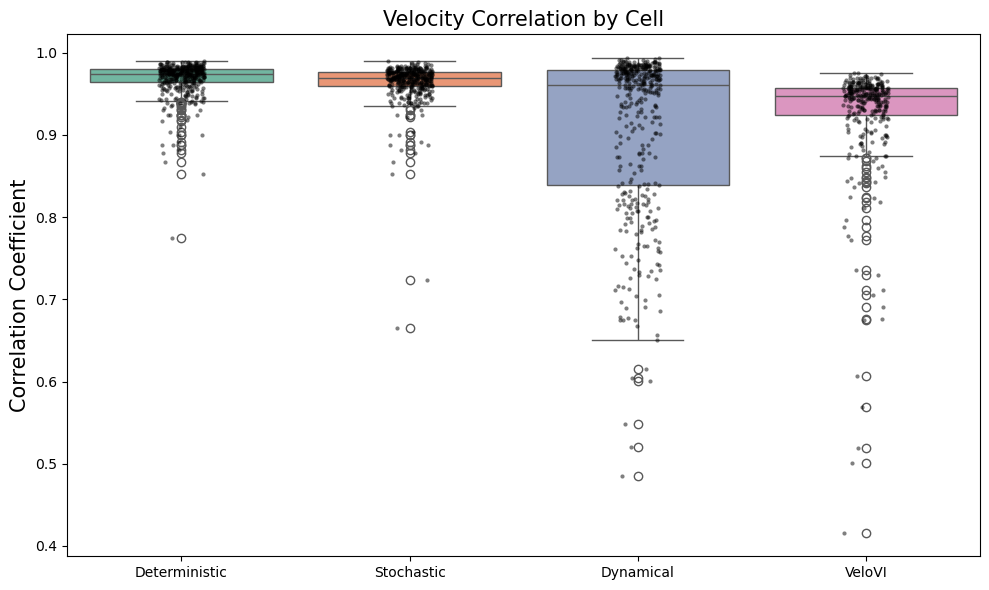

In [24]:
plot_velocity_correlations(cor)

# Worst Correlated Genes

In [29]:
sorted_items = sorted(velo_genes['dynamical'].items(), key=lambda item: item[1])

print(sorted_items)


[('398', 0.48520350944176904), ('34', 0.5197621501252652), ('198', 0.5482008221920528), ('303', 0.6006256540959231), ('313', 0.6039119943115187), ('16', 0.6150884736019728), ('171', 0.6509772253029339), ('214', 0.6565303553922771), ('312', 0.6673884724025684), ('180', 0.6744791130884906), ('360', 0.6747907898160375), ('390', 0.675371154063196), ('309', 0.6776015260881196), ('343', 0.6780970494400369), ('307', 0.6855355402260752), ('54', 0.6894467837477228), ('396', 0.6906482255903061), ('146', 0.697059669256598), ('179', 0.6994867767224894), ('14', 0.7036433473489416), ('241', 0.7055699723738365), ('357', 0.7115723304160215), ('262', 0.7128772243642159), ('43', 0.714711510119513), ('233', 0.7160735833729185), ('204', 0.7244170606112246), ('47', 0.7254836005010963), ('172', 0.7283280560888665), ('24', 0.7295541515049742), ('82', 0.733461361910476), ('92', 0.7349523275975931), ('67', 0.7352531019519302), ('61', 0.7364786173795527), ('371', 0.7415334930347959), ('345', 0.7431171156970664)

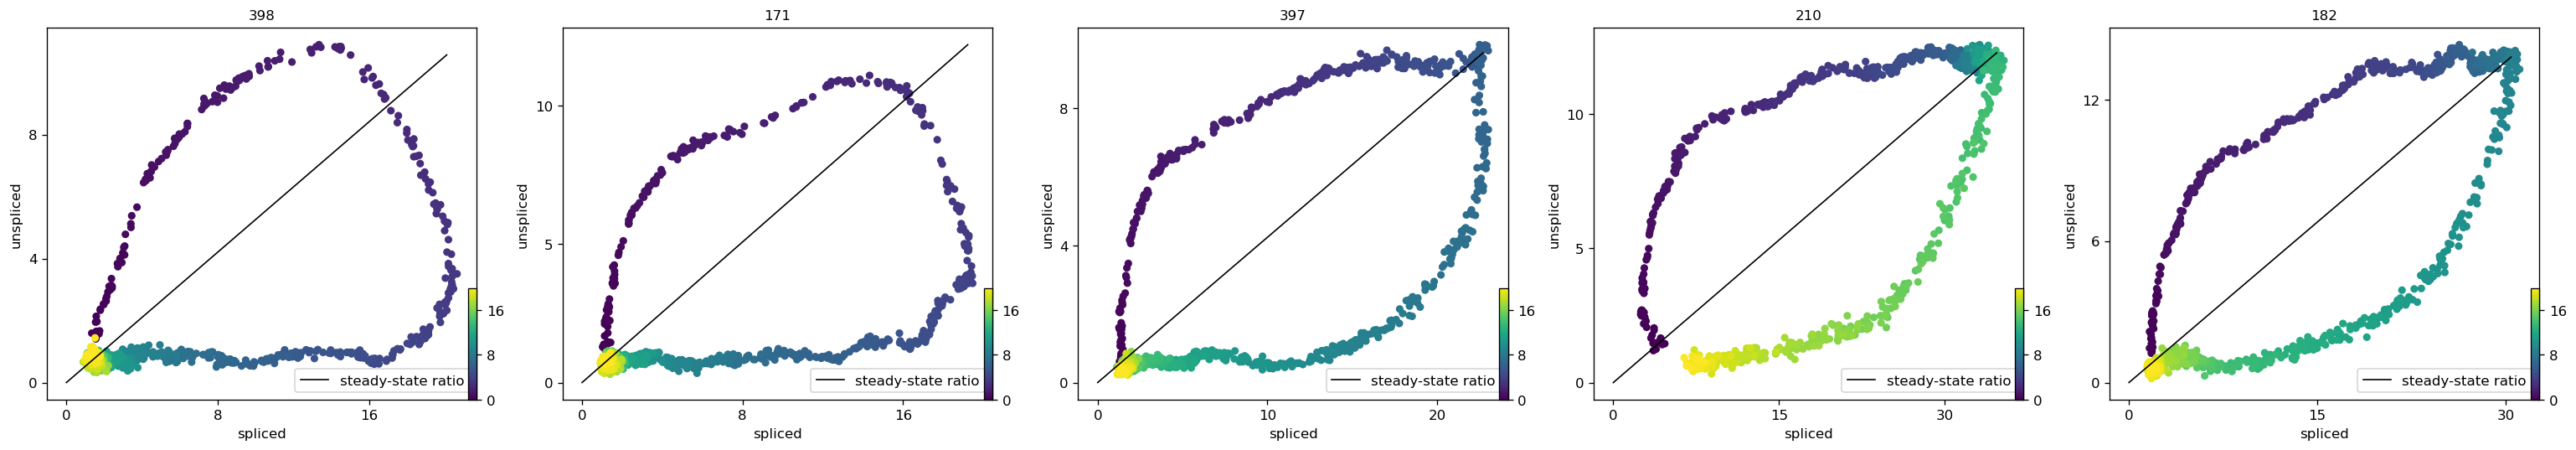

In [30]:
scv.pl.scatter(adata_dict['adata_s_u_1000obs_400genes_deterministic'],color="true_t", basis=['398','171','397','210','182'], ncols=5, frameon=True,dpi=120)

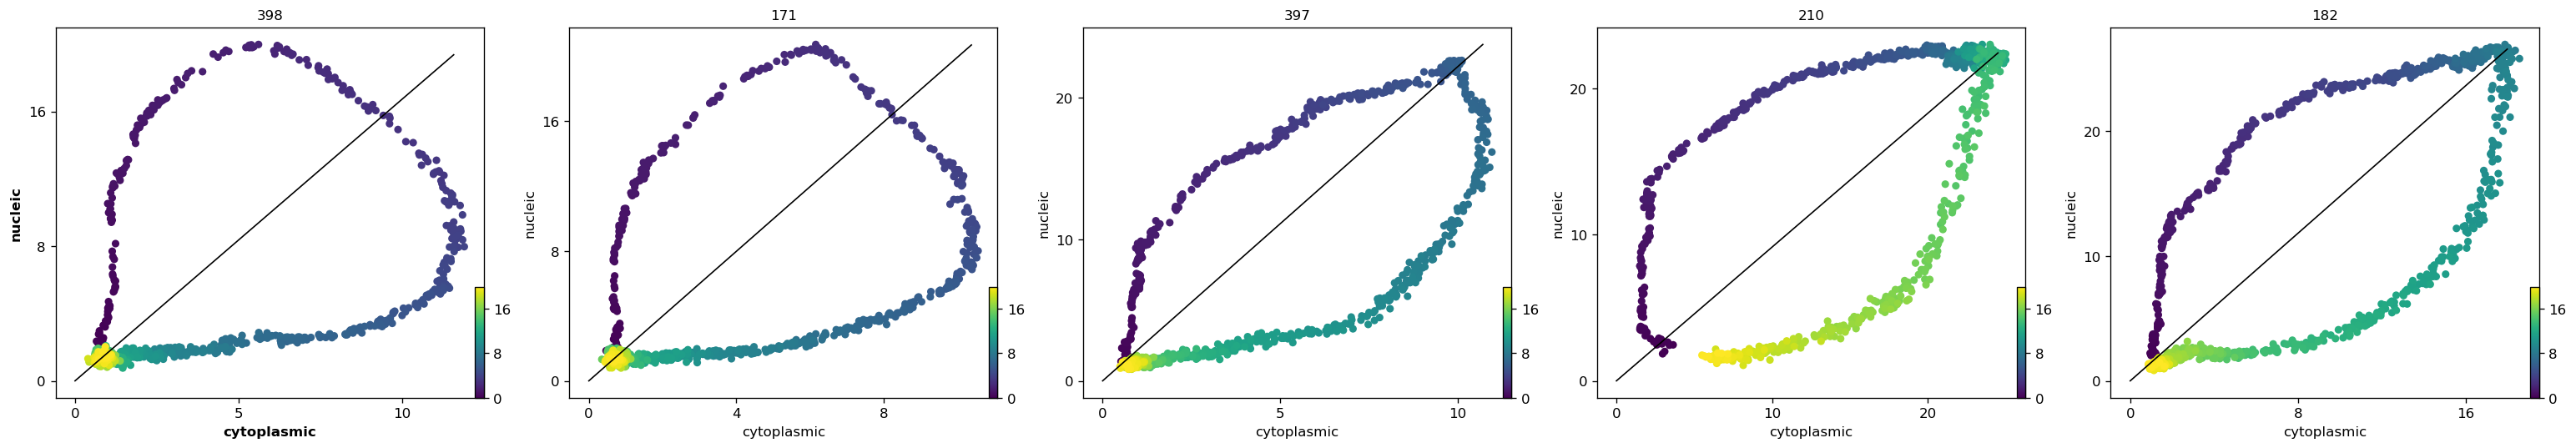

In [31]:
scv.pl.scatter(adata_dict['adata_n_c_1000obs_400genes_deterministic'],color="true_t", basis=['398','171','397','210','182'], ncols=5,dpi=120,ylabel='nucleic',xlabel='cytoplasmic')

# Important genes 

In [202]:
pd.set_option('display.max_rows', 10)

In [210]:
pd.set_option('display.max_rows', None)

In [235]:
pd.set_option('display.max_rows', 20)

## Velocity Correlation by Cell

In [32]:
cell_corr, b = compute_velocity_correlations(adata_dict, mode='by_cell')

Processing velocity type: stochastic
Processing velocity type: dynamical
Processing velocity type: velovi
Processing velocity type: deterministic


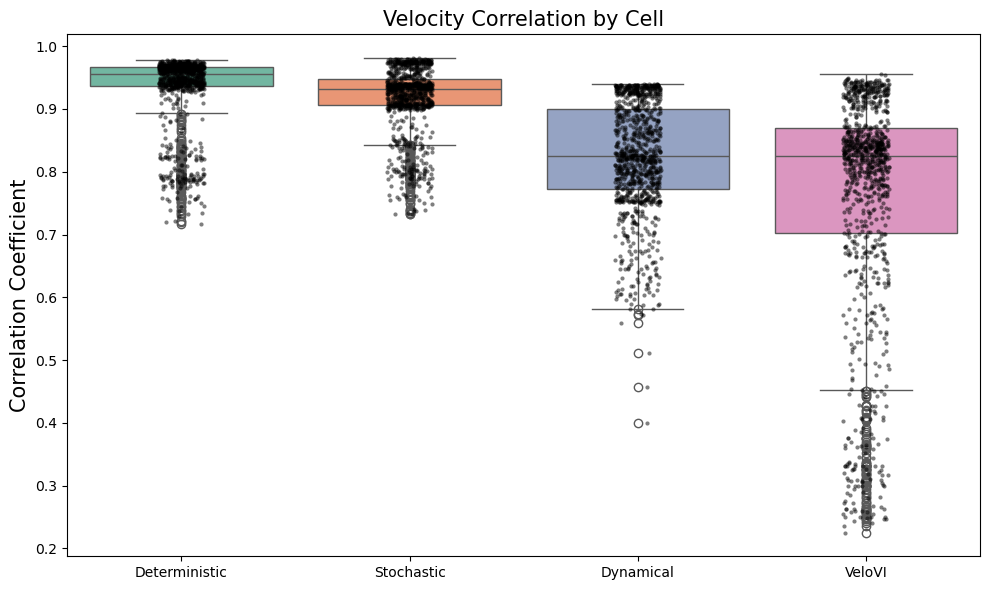

In [33]:
plot_velocity_correlations(cell_corr)

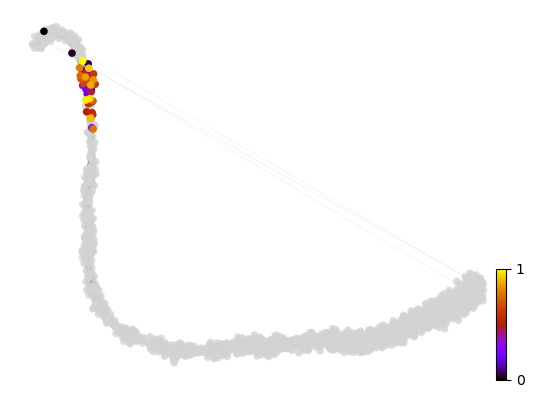

In [34]:
x, y = scv.utils.get_cell_transitions(adata_dict['adata_s_u_1000obs_400genes_velovi'], basis='umap', starting_cell=20)
ax = scv.pl.velocity_graph(adata_dict['adata_s_u_1000obs_400genes_dynamical'], c='lightgrey', edge_width=.05, show=False)
ax = scv.pl.scatter(adata_dict['adata_s_u_1000obs_400genes_dynamical'], x=x, y=y, s=120, c='ascending', cmap='gnuplot', ax=ax)

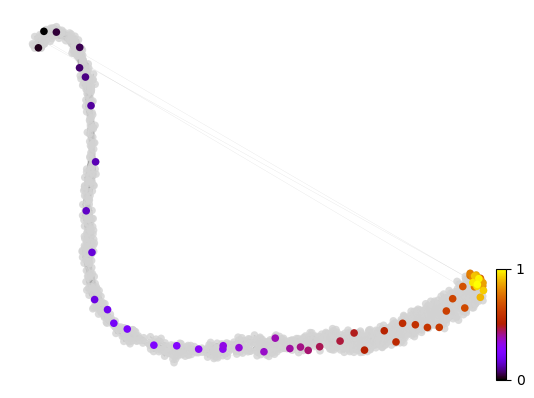

In [35]:
x, y = scv.utils.get_cell_transitions(adata_dict['adata_s_u_1000obs_400genes_dynamical'], basis='umap', starting_cell=20)
ax = scv.pl.velocity_graph(adata_dict['adata_s_u_1000obs_400genes_dynamical'], c='lightgrey', edge_width=.05, show=False)
ax = scv.pl.scatter(adata_dict['adata_s_u_1000obs_400genes_dynamical'], x=x, y=y, s=120, c='ascending', cmap='gnuplot', ax=ax)

# Check the important genes 

In [26]:
adata_dict['adata_n_c_1000obs_400genes_velovi']

AnnData object with n_obs × n_vars = 1000 × 75
    obs: 'true_t', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'leiden', 'velocity_self_transition', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition'
    var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden', 'log1p', 'neighbors', 'pca', 'umap', 'velocity_graph', 'velocity_graph_neg', 'velocity_params'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'fit_t', 'latent_time_velovi', 'spliced', 'spliced_cyt', 'spliced_nuc', 'true_velocity', 'unspliced', 'velocity'
    obsp: 'connectivities', 'distances'

In [47]:
for adata_name, adata in adata_dict.items():
    scv.tl.rank_velocity_genes(adata,groupby='leiden',min_corr=.3)

ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
   

In [49]:
dfs = scv.get_df(adata_dict['adata_s_u_1000obs_400genes_dynamical'].uns['rank_velocity_genes']['names'])
dfs.head(5)

,0,1,2,3,4,5,6,7,8,9,10
0,154,82,110,174,307,73,190,255,77,291,247
1,150,43,22,214,247,267,272,312,330,77,104
2,169,15,71,145,104,137,110,261,328,330,307
3,306,268,218,297,293,289,280,159,90,341,195
4,64,179,145,384,230,88,315,204,280,191,357


In [55]:
dfn = scv.get_df(adata_dict['adata_n_c_1000obs_400genes_dynamical'].uns['rank_velocity_genes']['names'])
dfs.head(5)

,0,1,2,3,4,5,6,7,8,9,10
0,6,133,137,380,202,219,381,149,250,133,35
1,288,371,84,219,151,380,161,286,371,202,202
2,133,115,379,393,35,393,325,52,290,123,123
3,367,6,128,209,138,319,317,395,133,371,151
4,41,391,355,376,31,128,290,8,199,250,288


In [ ]:
dfn = scv.get_df(adata_dict['adata_n_c_800obs_300genes_dynamical'].uns['rank_velocity_genes']['names'])
dfn.head(5)

In [64]:
adata_dict['adata_n_c_1000obs_400genes_deterministic'].var.iloc[[250,371,290,133,199]][['true_t_','velocity_genes']]

,true_t_,velocity_genes
250,6.257392,False
371,5.854411,False
290,6.397323,False
133,5.566678,False
199,7.178462,False


In [66]:
adata_dict['adata_n_c_1000obs_400genes_dynamical'].var.iloc[[250,371,290,133,199]][['true_t_','velocity_genes']]

,true_t_,velocity_genes
250,6.257392,True
371,5.854411,True
290,6.397323,True
133,5.566678,True
199,7.178462,True


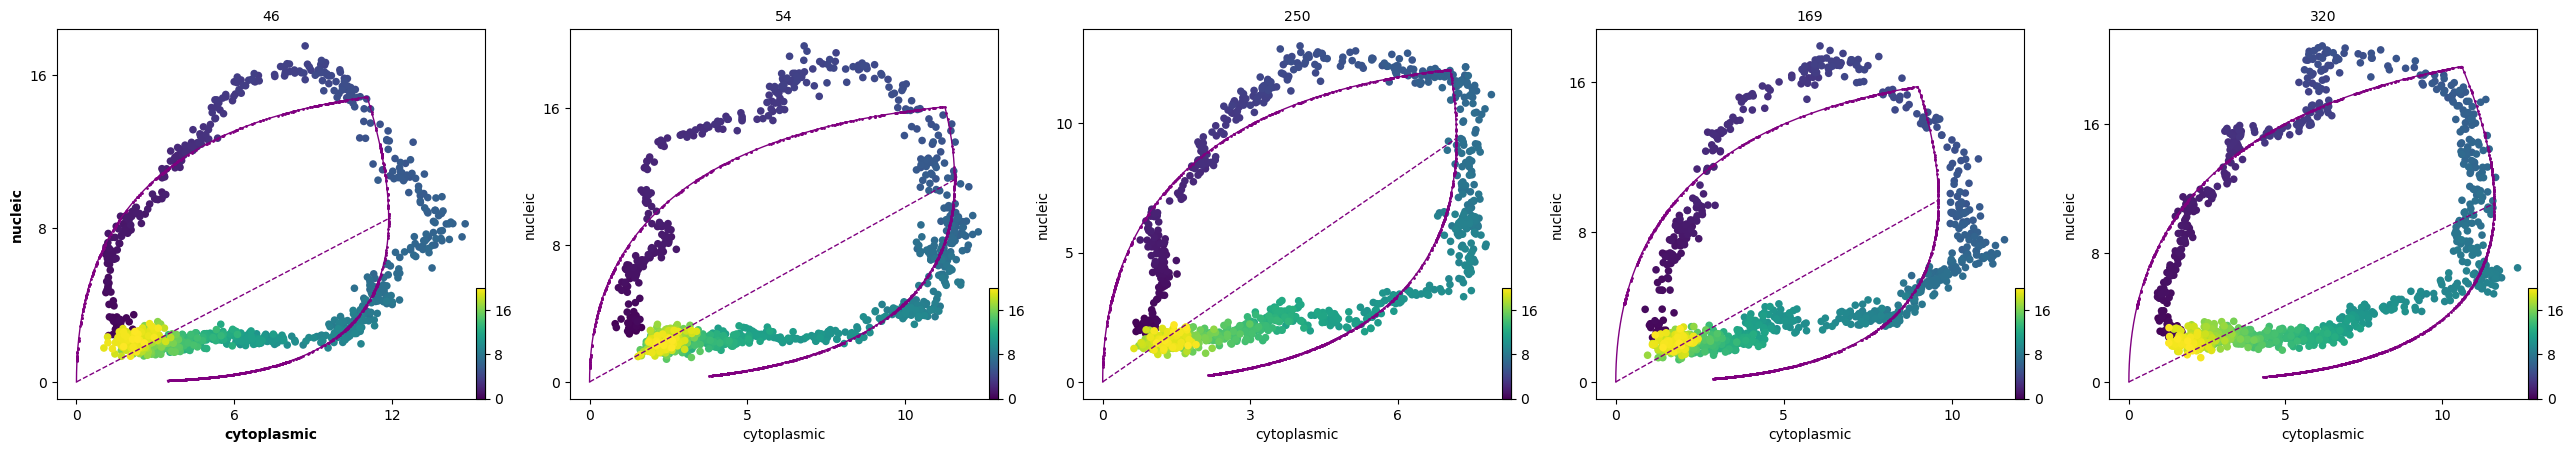

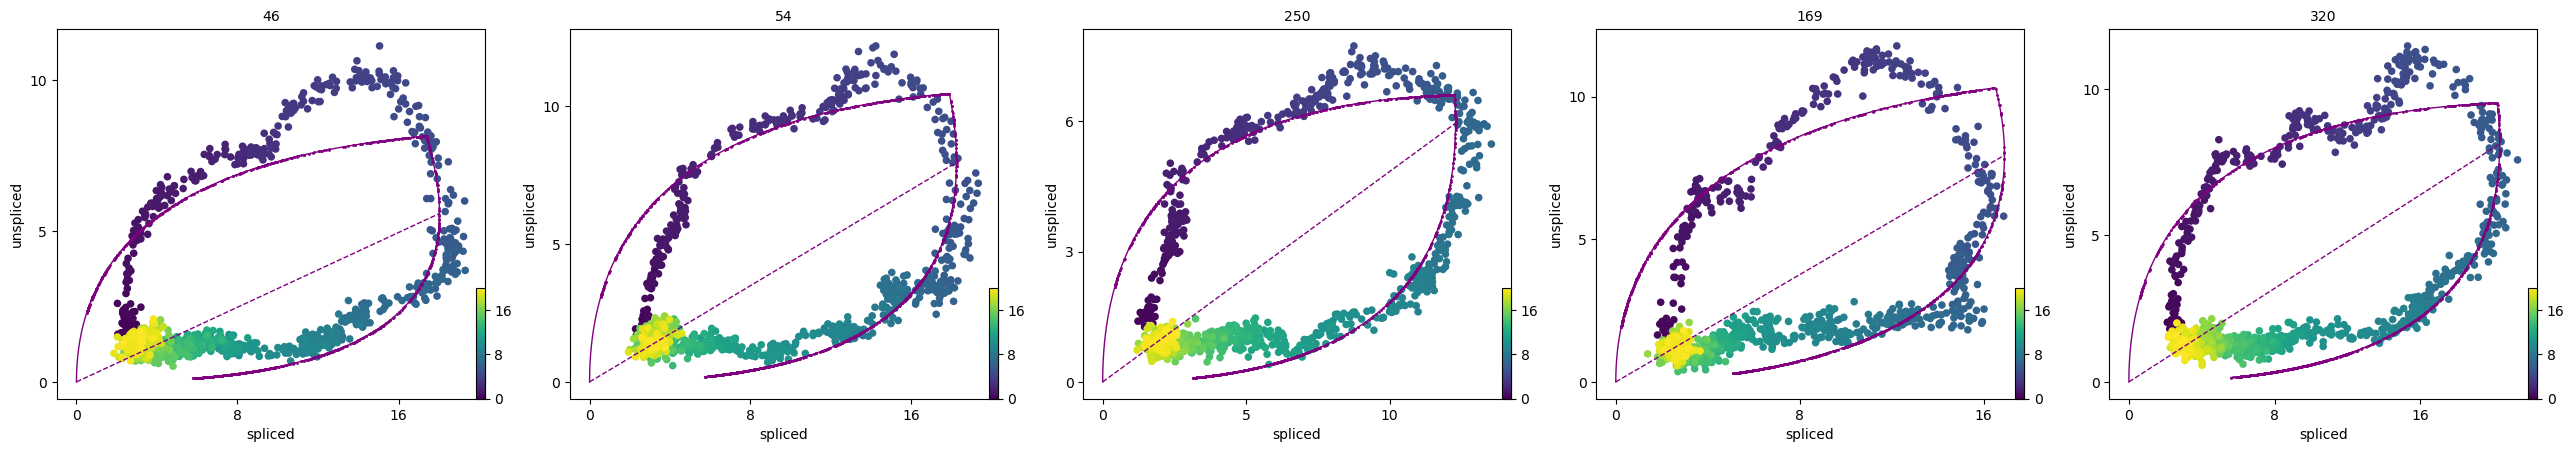

In [60]:
scv.pl.scatter(adata_dict['adata_n_c_1000obs_400genes_dynamical'], dfn.head()['8'][:5], ylabel='nucleic',xlabel='cytoplasmic' ,color='true_t')
scv.pl.scatter(adata_dict['adata_s_u_1000obs_400genes_dynamical'], dfn.head()['8'][:5], color= 'true_t')

### Compare all models

In [36]:
import scvelo as scv
import pandas as pd
import numpy as np
from itertools import combinations

def compute_pairwise_mean_correlations(adatas, mode='by_gene'):
    """
    Computes all pairwise mean correlations between datasets in a dictionary of AnnData objects.

    Parameters:
    - adatas (dict): Dictionary where keys are dataset names (str) and values are AnnData objects.
    - mode (str): 
        - 'by_gene': Compute correlations by genes (correlate across cells for each gene).
        - 'by_cell': Compute correlations by cells (correlate across genes for each cell).

    Returns:
    - pd.DataFrame: A DataFrame with dataset names as both rows and columns, containing mean correlations.
    """
    
    # Validate mode
    if mode not in ['by_gene', 'by_cell']:
        raise ValueError("Invalid mode. Choose 'by_gene' or 'by_cell'.")
    
    # Get all dataset names
    dataset_names = list(adatas.keys())
    
    # Initialize an empty DataFrame to store mean correlations
    correlation_matrix = pd.DataFrame(index=dataset_names, columns=dataset_names, dtype=float)
    
    # Iterate over all unique pairs (including self-pairs)
    for ds1, ds2 in combinations(dataset_names, 2):
        adata1 = adatas[ds1]
        adata2 = adatas[ds2]
        
        # Find common genes
        common_genes = adata1.var_names.intersection(adata2.var_names)
        if len(common_genes) == 0:
            print(f"No common genes between '{ds1}' and '{ds2}'. Skipping.")
            mean_corr = np.nan
        else:
            # Subset velocity matrices to common genes
            velo1 = adata1.layers.get('velocity')
            velo2 = adata2.layers.get('velocity')
            
            if velo1 is None or velo2 is None:
                print(f"Velocity layer not found in '{ds1}' or '{ds2}'. Skipping.")
                mean_corr = np.nan
            else:
                # Convert to DataFrame for easier handling
                velo_df1 = pd.DataFrame(velo1, index=adata1.obs_names, columns=adata1.var_names)
                velo_df2 = pd.DataFrame(velo2, index=adata2.obs_names, columns=adata2.var_names)
                
                # Subset to common genes
                velo_df1 = velo_df1[common_genes]
                velo_df2 = velo_df2[common_genes]
                
                if mode == 'by_gene':
                    # Compute correlation across cells for each gene
                    gene_corrs = []
                    for gene in common_genes:
                        v1 = velo_df1[gene].values
                        v2 = velo_df2[gene].values
                        # Handle NaNs
                        mask = ~np.isnan(v1) & ~np.isnan(v2)
                        if np.sum(mask) > 0:
                            corr = np.corrcoef(v1[mask], v2[mask])[0, 1]
                            gene_corrs.append(corr)
                    # Compute mean correlation, ignoring NaNs
                    if gene_corrs:
                        mean_corr = np.nanmean(gene_corrs)
                    else:
                        mean_corr = np.nan
                        
                elif mode == 'by_cell':
                    # Find common cells
                    common_cells = adata1.obs_names.intersection(adata2.obs_names)
                    if len(common_cells) == 0:
                        print(f"No common cells between '{ds1}' and '{ds2}'. Skipping.")
                        mean_corr = np.nan
                    else:
                        # Subset velocity matrices to common cells
                        velo_df1 = velo_df1.loc[common_cells]
                        velo_df2 = velo_df2.loc[common_cells]
                        
                        # Compute correlation across genes for each cell
                        cell_corrs = []
                        for cell in common_cells:
                            v1 = velo_df1.loc[cell].values
                            v2 = velo_df2.loc[cell].values
                            # Handle NaNs
                            mask = ~np.isnan(v1) & ~np.isnan(v2)
                            if np.sum(mask) > 0:
                                corr = np.corrcoef(v1[mask], v2[mask])[0, 1]
                                cell_corrs.append(corr)
                        # Compute mean correlation, ignoring NaNs
                        if cell_corrs:
                            mean_corr = np.nanmean(cell_corrs)
                        else:
                            mean_corr = np.nan
                        
        # Assign the mean correlation to both (ds1, ds2) and (ds2, ds1)
        correlation_matrix.at[ds1, ds2] = mean_corr
        correlation_matrix.at[ds2, ds1] = mean_corr
    
    # Fill diagonal with 1.0 (correlation of a dataset with itself)
    np.fill_diagonal(correlation_matrix.values, 1.0)
    
    return correlation_matrix


In [37]:
cor_gene = compute_pairwise_mean_correlations(adata_dict)
cor_cell = compute_pairwise_mean_correlations(adata_dict, mode='by_cell')

In [38]:
name_mapping = {}

# Define data type mapping
data_type_map = {
    'n_c': 'in situ',
    's_u': 'splicing'
}

# Loop over each name in the index (and columns)
for name in cor_gene.index:
    parts = name.split('_')
    # Extract data type (e.g., 'n_c' or 's_u')
    data_type = parts[1] + '_' + parts[2]
    data_type_label = data_type_map.get(data_type, data_type)
    
    # Extract velocity model (e.g., 'deterministic', 'stochastic', etc.)
    velocity_model = parts[5]
    # Capitalize the velocity model name
    velocity_model_label = velocity_model.capitalize()
    
    # Combine to form the new label
    new_label = f"{velocity_model_label} {data_type_label}"
    
    # Add to the mapping
    name_mapping[name] = new_label



In [39]:
# Rename the index and columns using the mapping
corr_by_gene = cor_gene.rename(index=name_mapping, columns=name_mapping)
corr_by_cell = cor_cell.rename(index=name_mapping, columns=name_mapping)

In [110]:
sns.reset_defaults()

In [121]:
corr_by_cell

,Deterministic in situ,Dynamical in situ,Stochastic in situ,Velovi in situ,Deterministic splicing,Dynamical splicing,Stochastic splicing,Velovi splicing
Deterministic in situ,1.000000,0.871842,0.996633,0.922220,0.948023,0.904140,0.953219,0.941980
Dynamical in situ,0.871842,1.000000,0.879383,0.921689,0.796533,0.911572,0.836108,0.911565
Stochastic in situ,0.996633,0.879383,1.000000,0.956145,0.939231,0.901857,0.949370,0.939597
Velovi in situ,0.922220,0.921689,0.956145,1.000000,0.860380,0.904732,0.911824,0.925169
Deterministic splicing,0.948023,0.796533,0.939231,0.860380,1.000000,0.874088,0.993553,0.918649
Dynamical splicing,0.904140,0.911572,0.901857,0.904732,0.874088,1.000000,0.885769,0.940460
Stochastic splicing,0.953219,0.836108,0.949370,0.911824,0.993553,0.885769,1.000000,0.948031
Velovi splicing,0.941980,0.911565,0.939597,0.925169,0.918649,0.940460,0.948031,1.000000


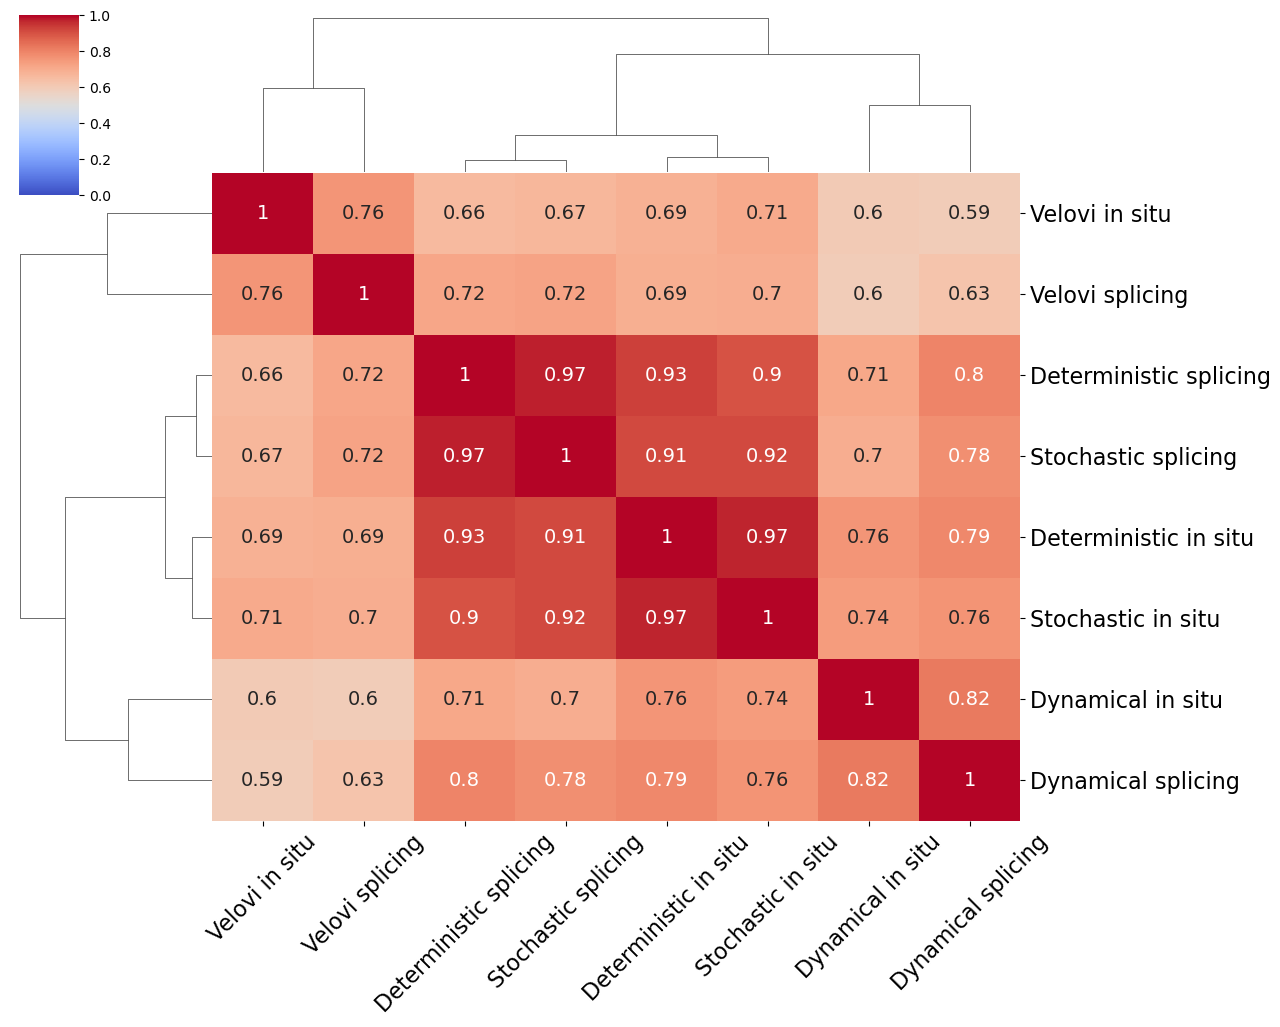

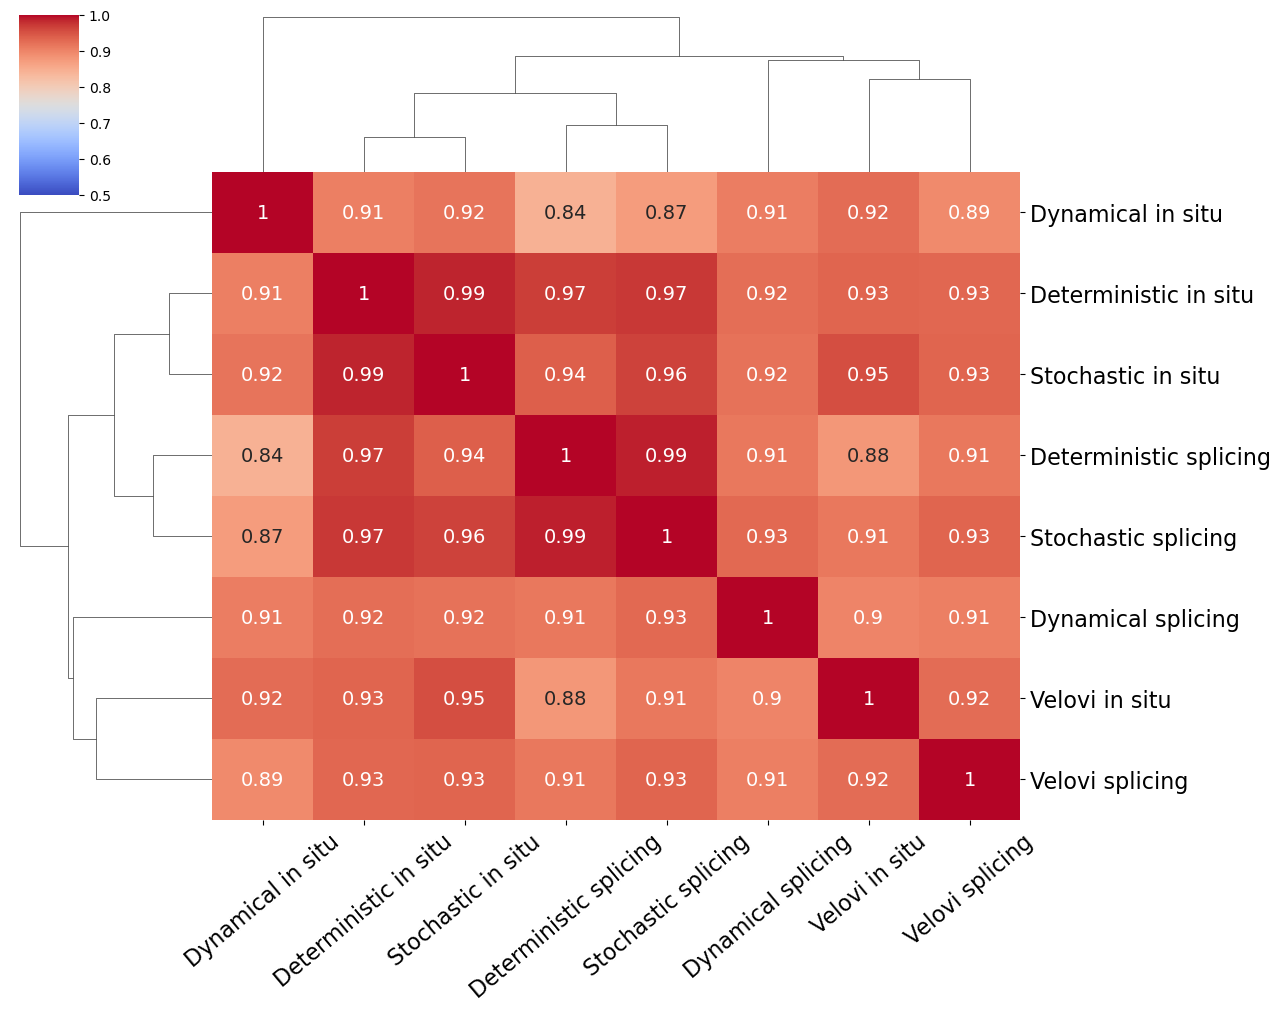

In [40]:
# Clustermap for correlation by cell
clustermap_cell = sns.clustermap(corr_by_cell, cmap='coolwarm', annot=True, figsize=(12, 10), vmin=0, vmax=1,annot_kws={"size":14})

# Modify tick labels for the cell clustermap
clustermap_cell.ax_heatmap.set_xticklabels(
    clustermap_cell.ax_heatmap.get_xticklabels(),
    rotation=45,  # Tilt the labels by 45 degrees
    fontsize=16   # Increase font size
)
clustermap_cell.ax_heatmap.set_yticklabels(
    clustermap_cell.ax_heatmap.get_yticklabels(),
    fontsize=16   # Increase font size
)

# Clustermap for correlation by gene
clustermap_gene = sns.clustermap(corr_by_gene, cmap='coolwarm', annot=True, figsize=(12, 10), vmin=0.5, vmax=1,annot_kws={"size":14})

# Modify tick labels for the gene clustermap
clustermap_gene.ax_heatmap.set_xticklabels(
    clustermap_gene.ax_heatmap.get_xticklabels(),
    rotation=40,  # Tilt the labels by 45 degrees
    fontsize=16   # Increase font size
)
clustermap_gene.ax_heatmap.set_yticklabels(
    clustermap_gene.ax_heatmap.get_yticklabels(),
    fontsize=16   # Increase font size
)

plt.show()


# Further plot for analysis- gene simulation 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Your sorted data arrays
def plot_gene_counts(n_obs: None, n_var : None, gene : 0):
    adata = adata_dict[f'adata_n_c_{n_obs}obs_{n_var}genes_deterministic']
    unspliced = adata.layers['unspliced'][:,gene]- adata.layers['spliced_nuc'][:,gene] 
    spliced_nuc = adata.layers['spliced_nuc'][:,gene]
    spliced_cyto = adata.layers['spliced'][:,gene]

    t_max = adata.obs['true_t'].max()

    # Assuming the x-values are indices or known values
    x_values = np.arange(len(unspliced))
    scaling_factor = t_max / n_obs
    x_values_scaled = x_values * scaling_factor

    # Define a function for moving average smoothing
    def moving_average(y, window_size):
        return np.convolve(y, np.ones(window_size)/window_size, mode='valid')

    # Set the window size for smoothing
    window_size = 15  # Adjust the window size as needed

    # Calculate the moving averages for each dataset
    smooth_data1 = moving_average(unspliced, window_size)
    smooth_data2 = moving_average(spliced_nuc, window_size)
    smooth_data3 = moving_average(spliced_cyto, window_size)

    smooth_x_values = x_values[:len(smooth_data1)] + (window_size // 2)
    smooth_x_values_scaled = smooth_x_values * scaling_factor

    # Plot the smooth lines for each dataset using scaled x-values
    plt.plot(smooth_x_values_scaled, smooth_data1, color='blue', linewidth=2, label='unspliced')
    plt.plot(smooth_x_values_scaled, smooth_data2, color='red', linewidth=2, label='spliced nucleic')
    plt.plot(smooth_x_values_scaled, smooth_data3, color='green', linewidth=2, label='spliced cytoplasmic')


    true_t = adata.var['true_t_'][gene] 


    # Draw the vertical line using the scaled x-value
    plt.axvline(x=true_t, color='black', linestyle='--', linewidth=1, label='switch time')

    # Add labels and title
    plt.xlabel('Time')
    plt.ylabel('Abundances')
    plt.title('mRNA abundances change over time')
    plt.legend(loc = 'upper right',fontsize = 8)
    plt.grid(True)

    # Display the plot
    plt.show()


In [2]:
plot_gene_counts(n_obs=1000,n_var=400,gene=371)

NameError: name 'adata_dict' is not defined

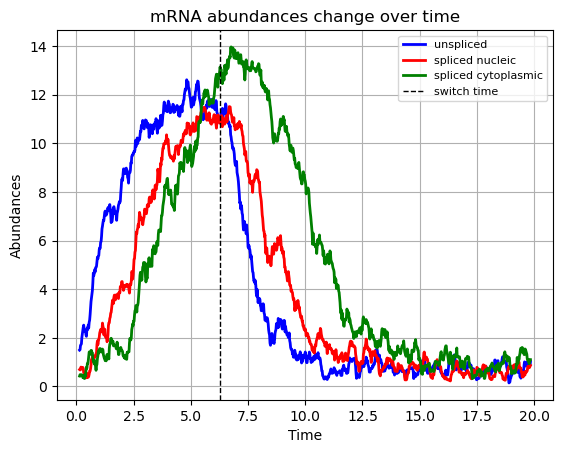

In [43]:
plot_gene_counts(n_obs=1000,n_var=400,gene=250)

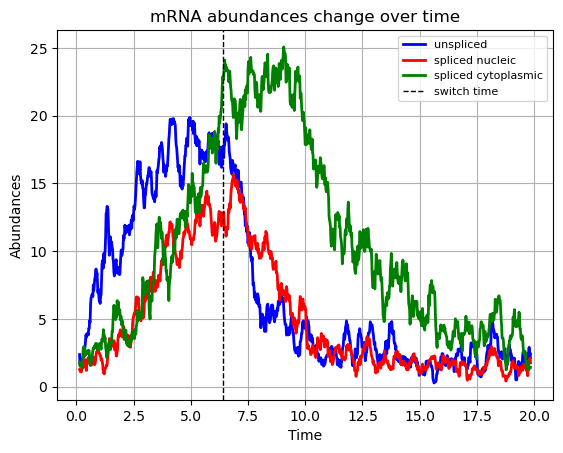

In [97]:
plot_gene_counts(n_obs=1000,n_var=400,gene=290)

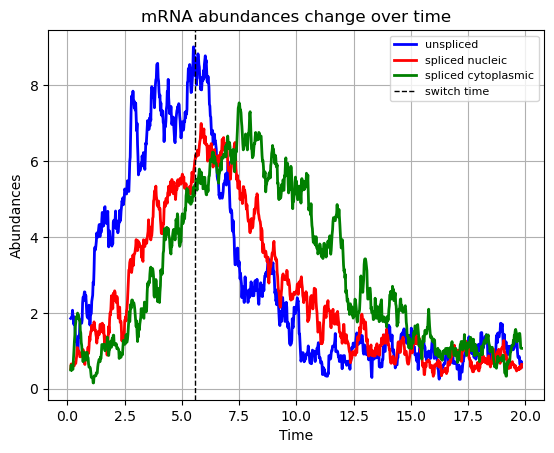

In [99]:
plot_gene_counts(n_obs=1000,n_var=400,gene=133)

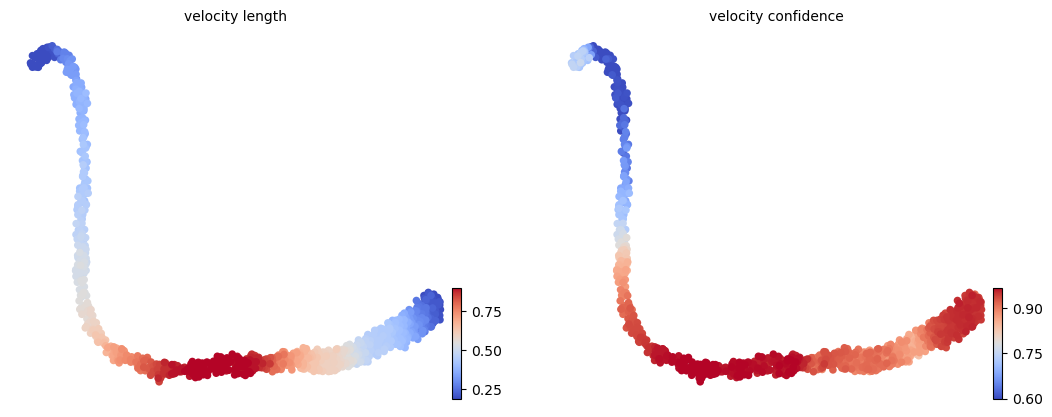

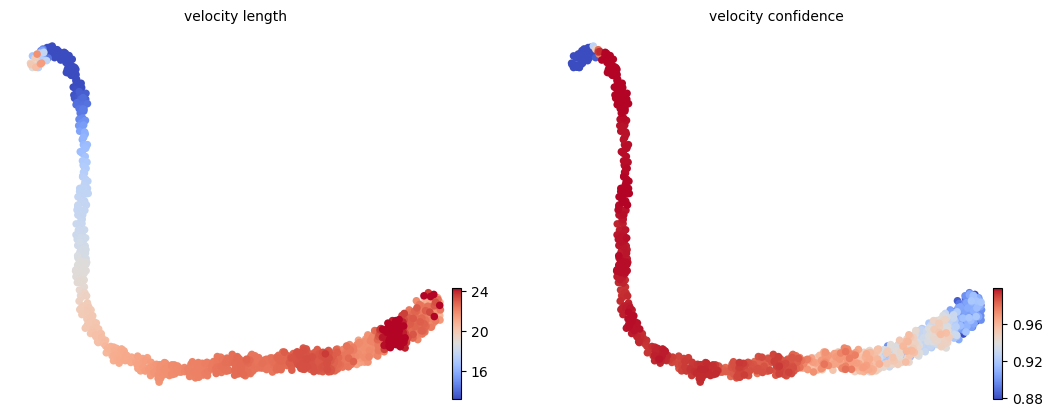

In [44]:
# scv.tl.velocity_confidence(adata_dict['adata_n_c_1000obs_400genes_deterministic'])
keys = 'velocity_length', 'velocity_confidence'
scv.pl.scatter((adata_dict['adata_n_c_1000obs_400genes_velovi']), c=keys, cmap='coolwarm', perc=[5, 95])
scv.pl.scatter((adata_dict['adata_n_c_1000obs_400genes_dynamical']), c=keys, cmap='coolwarm', perc=[5, 95])

In [99]:
adata_dict['adata_n_c_1000obs_400genes_deterministic'].var['true_ratio']

0      0.697565
1      1.302664
2      1.349254
3      1.098988
4      0.942781
         ...   
395    1.207340
396    0.991523
397    0.941190
398    0.622191
399    0.959165
Name: true_ratio, Length: 400, dtype: float64

In [95]:
adata_dict['adata_n_c_1000obs_400genes_stochastic'].var['velocity_gamma']

0      1.019544
1      1.195107
2      1.273457
3      1.539850
4      1.320508
         ...   
395    1.185032
396    1.629223
397    1.780644
398    1.185437
399    1.467164
Name: velocity_gamma, Length: 400, dtype: float32

In [130]:
adata_dict['adata_s_u_1000obs_400genes_deterministic'].var.velocity_genes.value_counts()

velocity_genes
True     243
False    157
Name: count, dtype: int64

In [132]:
from scipy.stats import pearsonr

In [116]:
adata_dict['adata_n_c_1000obs_400genes_velovi'].var['true_ratio'].mean()

1.1222267386905913

In [117]:
adata_dict['adata_s_u_1000obs_400genes_velovi'].var['true_ratio'].mean()

0.38193632720123355

In [166]:
a = adata_dict['adata_n_c_1000obs_400genes_velovi'].var['true_ratio']
b = (adata_dict['adata_n_c_1000obs_400genes_velovi'].var['fit_gamma'] / adata_dict['adata_n_c_1000obs_400genes_velovi'].var['fit_beta'])*400


In [146]:
read_dictionary = np.load('data/vae/01_comp.npy',allow_pickle='TRUE').item()
vae = read_dictionary['adata_n_c_1000obs_400genes_velovi']

In [149]:
c = vae.get_rates()["gamma"]/vae.get_rates()['beta']

In [171]:
a = adata_dict['adata_n_c_1000obs_400genes_velovi'].var['true_t_']
b =  adata_dict['adata_n_c_1000obs_400genes_velovi'].var['fit_t_']

In [180]:
c = adata_dict['adata_n_c_1000obs_400genes_dynamical'].var['true_t_']
d =  adata_dict['adata_n_c_1000obs_400genes_dynamical'].var['fit_t_']

In [45]:
for key, adata in adata_dict.items():
    true_beta = adata.var['true_beta']
    true_nu = adata.var['true_nu']
    true_gamma = adata.var['true_gamma']
    if 's_u' in key:
        true_ratio = (1/true_beta )* (1/((1/true_gamma)+(1/true_nu)))
    else:
        true_ratio = true_gamma*((1/true_nu)+(1/true_beta))
    adata.var['true_ratio'] = true_ratio

In [46]:
def plot_model_ratios(adata_dict):
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy.stats import pearsonr
    import numpy as np
    import pandas as pd

    # Create a dictionary to group adatas by model type
    model_types = {}
    for key in adata_dict.keys():
        # Extract model type and data type from key
        parts = key.split('_')
        # Assuming the last part is the model type
        model_type = parts[-1]
        # Data type is 'n_c' or 's_u'
        if '_n_c_' in key:
            data_type = 'in situ'  # 'n_c' data
        elif '_s_u_' in key:
            data_type = 'splicing'  # 's_u' data
        else:
            continue  # Skip if data type is unknown

        if model_type not in model_types:
            model_types[model_type] = {'in situ': [], 'splicing': []}
        # Append the key to the appropriate list
        model_types[model_type][data_type].append(key)

    # Now for each model type, create a scatter plot
    for model_type, data_dict in model_types.items():
        # Collect data from 'in situ' and 'splicing'
        df_list = []
        for data_type in ['in situ', 'splicing']:
            keys = data_dict[data_type]
            for key in keys:
                adata = adata_dict[key]
                # Calculate 'calculated_ratio'
                if model_type in ['dynamical', 'velovi']:
                    calculated_ratio = adata.var['fit_gamma'] / adata.var['fit_beta']
                else:
                    calculated_ratio = adata.var['velocity_gamma']

                # Retrieve 'true_ratio'
                true_ratio = adata.var['true_ratio']

                # Identify common genes
                common_genes = calculated_ratio.index.intersection(true_ratio.index)

                # Subset to common genes
                calculated_ratio = calculated_ratio.loc[common_genes]
                true_ratio = true_ratio.loc[common_genes]

                # Drop NaN values
                valid = calculated_ratio.notna() & true_ratio.notna()
                calculated_ratio = calculated_ratio[valid]
                true_ratio = true_ratio[valid]

                # Create a DataFrame
                df = pd.DataFrame({
                    'True Ratio': true_ratio,
                    'Calculated Ratio': calculated_ratio,
                    'Data Type': data_type
                })

                df_list.append(df)

        # Concatenate all data
        plot_df = pd.concat(df_list, ignore_index=True)

        # Compute Pearson correlation for each data type
        r_values = {}
        for data_type in ['in situ', 'splicing']:
            subset = plot_df[plot_df['Data Type'] == data_type]
            if len(subset) > 1:
                r, _ = pearsonr(subset['True Ratio'], subset['Calculated Ratio'])
                r_values[data_type] = r
            else:
                r_values[data_type] = np.nan

        # Create scatter plot
        plt.figure(figsize=(6, 6))
        sns.scatterplot(
            data=plot_df,
            x='True Ratio',
            y='Calculated Ratio',
            hue='Data Type',
            palette={'in situ': 'blue', 'splicing': 'orange'}
        )

        # Plot identity line
        min_val = min(plot_df['True Ratio'].min(), plot_df['Calculated Ratio'].min())
        max_val = max(plot_df['True Ratio'].max(), plot_df['Calculated Ratio'].max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--')

        # Set title with Pearson correlations
        title = f"{model_type.capitalize()} \n"
        for data_type in ['in situ', 'splicing']:
            r = r_values[data_type]
            if not np.isnan(r):
                title += f"{data_type.capitalize()} Pearson r = {r:.2f}   "
            else:
                title += f"{data_type.capitalize()} Pearson r = NaN   "
        plt.title(title.strip(), fontsize=14)
        plt.xlabel('True Ratio', fontsize=12)
        plt.ylabel('Calculated Ratio', fontsize=12)

        # Adjust layout and display plot
        plt.tight_layout()
        plt.show()


In [114]:
adata_dict['adata_n_c_1000obs_400genes_deterministic']

AnnData object with n_obs × n_vars = 1000 × 400
    obs: 'true_t', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'leiden', 'velocity_self_transition', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition'
    var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes', 'spearmans_score', 'velocity_score', 'true_ratio'
    uns: 'leiden', 'log1p', 'neighbors', 'pca', 'umap', 'velocity_graph', 'velocity_graph_neg', 'velocity_params', 'rank_velocity_genes'
    obsm: 'X_pca', 'X_umap', 'velocity_umap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'spliced', 'spliced_cyt', 'spliced_nuc', 'true_velocity', 'unspliced', 'velocity'
    obsp: 'connectivities', 'distances'

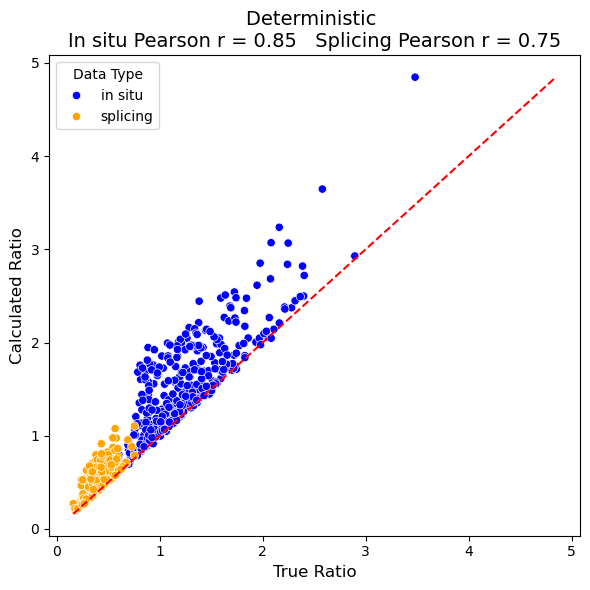

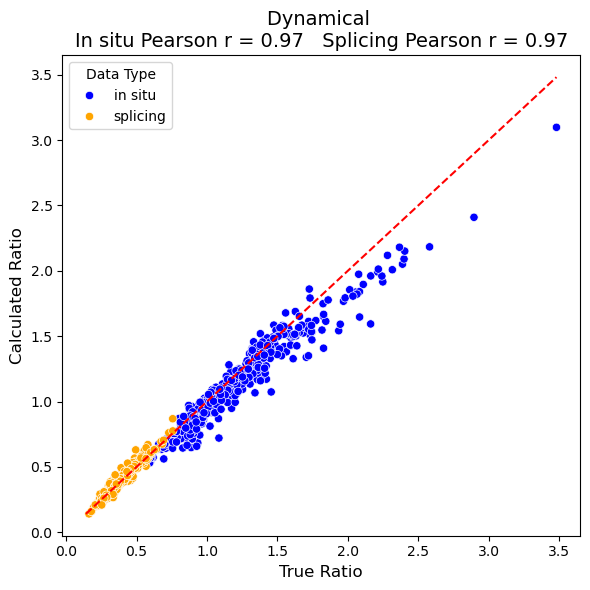

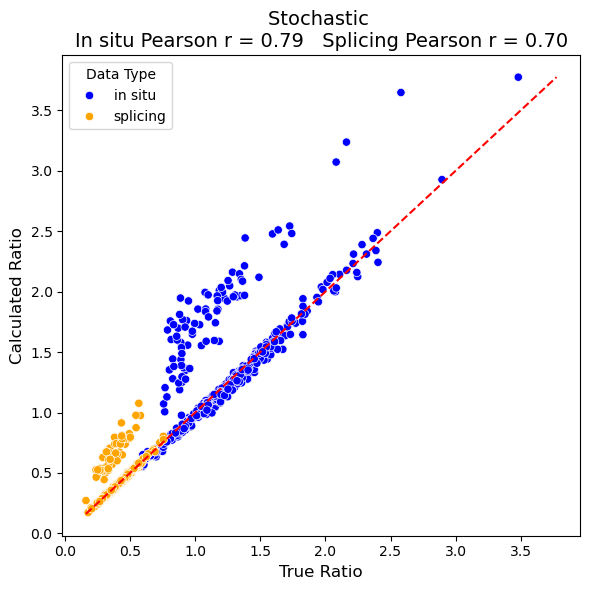

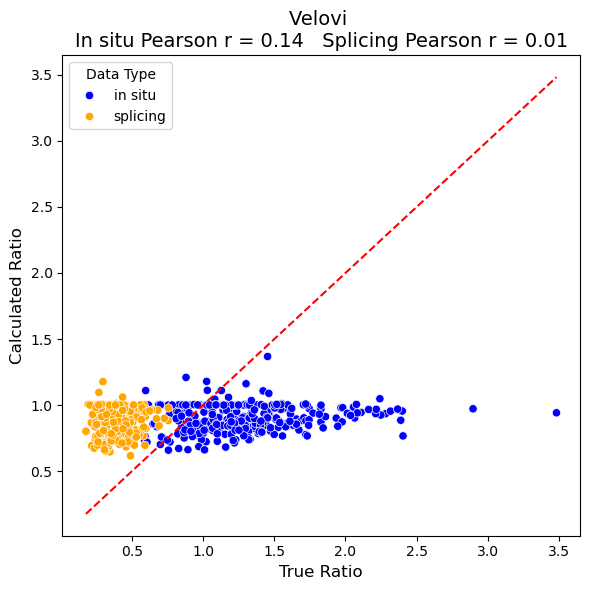

In [47]:
plot_model_ratios(adata_dict=adata_dict)

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

def compute_pearson_correlations_t(adatas, axis='by_gene'):
    """
    Computes Pearson correlations between 'true_velocity' and 'velocity' matrices for each AnnData object.

    Parameters:
    - adatas (dict): Dictionary with keys as dataset names and values as AnnData objects.
    - axis (str): 'by_gene' or 'by_cell' to specify the correlation axis.

    Returns:
    - correlations (dict): Dictionary with dataset names as keys and mean Pearson correlation as values.
    """
    correlations = {}
    correlations_mean ={}
    for key, adata in adatas.items():
        if 'dynamical' in key or 'velovi' in key:
            model_type = 'dynamical'
        elif 'deterministic' in key:
            model_type = 'deterministic'
        elif 'stochastic' in key:
            model_type = 'stochastic'
        else:
            model_type = 'unknown'
        
        true_vel = adata.layers['true_velocity']
        vel = adata.layers['velocity']
        
        if model_type == 'velovi':
            common_genes = adata.var_names.intersection(adata.var_names)
            true_vel = true_vel[:, adata.var_names]
        else:
            common_genes = np.arange(true_vel.shape[1])
        
        if model_type == 'dynamical' or model_type == 'velovi':
            mask = ~np.isnan(vel)
            true_vel = np.where(mask, true_vel, np.nan)
        
        if axis == 'by_gene':
            corr_list = []
            for gene_idx in range(true_vel.shape[1]):
                true_vals = true_vel[:, gene_idx]
                vel_vals = vel[:, gene_idx]
                valid = ~np.isnan(true_vals) & ~np.isnan(vel_vals)
                if np.sum(valid) > 1:
                    r, _ = pearsonr(true_vals[valid], vel_vals[valid])
                    corr_list.append(r)
            mean_corr = np.nanmean(corr_list) if corr_list else np.nan
        elif axis == 'by_cell':
            corr_list = []
            for cell_idx in range(true_vel.shape[0]):
                true_vals = true_vel[cell_idx, :]
                vel_vals = vel[cell_idx, :]
                valid = ~np.isnan(true_vals) & ~np.isnan(vel_vals)
                if np.sum(valid) > 1:
                    r, _ = pearsonr(true_vals[valid], vel_vals[valid])
                    corr_list.append(r)
            mean_corr = np.nanmean(corr_list) if corr_list else np.nan
            
        else:
            raise ValueError("Axis must be 'by_gene' or 'by_cell'")
        
        correlations_mean[key] = mean_corr
        correlations[key] = corr_list

    
    return correlations_mean, correlations


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_correlation_boxplots(correlation_dict):
    """
    Plots box plots of Pearson correlations for each velocity type, 
    with 'n_c' and 's_u' data types side by side and colored accordingly.
    
    Parameters:
    - correlation_dict (dict): Dictionary with keys as dataset names and values as lists of correlation coefficients.
    """
    # Prepare the data
    data = []
    for key, corr_values in correlation_dict.items():
        parts = key.split('_')
        data_type = 'n_c' if 'n_c' in key else 's_u' if 's_u' in key else 'unknown'
        velocity_type = parts[-1]  # 'deterministic', 'stochastic', 'dynamical', 'velovi'

        for corr in corr_values:
            data.append({
                'velocity_type': velocity_type,
                'data_type': data_type,
                'correlation': corr
            })

    # Create DataFrame
    df = pd.DataFrame(data)

    # Define the order of velocity types
    velocity_type_order = ['deterministic', 'stochastic', 'dynamical', 'velovi']

    # Define color palette
    palette = {'n_c': '#1f77b4', 's_u': '#ff7f0e'}

    # Create the box plot
    plt.figure(figsize=(12, 8))
    sns.boxplot(
        x='velocity_type',
        y='correlation',
        hue='data_type',
        data=df,
        order=velocity_type_order,
        palette=palette
    )

    sns.stripplot(
        x='velocity_type',
        y='correlation',
        hue='data_type',
        data=df,
        order=velocity_type_order,
        # palette=black,
        dodge=True,
        jitter=True,
        size=3,
        color='black',
        alpha=0.4,
        edgecolor='gray'
    )

    # Set plot title and labels
    plt.title('True Velocity-Velocity Pearson Correlations', fontsize=16)
    plt.xlabel('Velocity Type', fontsize=14)
    plt.ylabel('Pearson Correlation Coefficient', fontsize=14)

    # Adjust legend
    plt.legend()

    # Rotate x-axis labels
    # plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=12)

    # Optimize layout
    plt.tight_layout()

    # Display the plot
    plt.show()

# Example usage:
# Assuming 'correlation_dict' is your precomputed correlation dictionary
# plot_correlation_boxplots(correlation_dict)


In [106]:
a , b = compute_pearson_correlations_t(adata_dict,axis='by_cell')

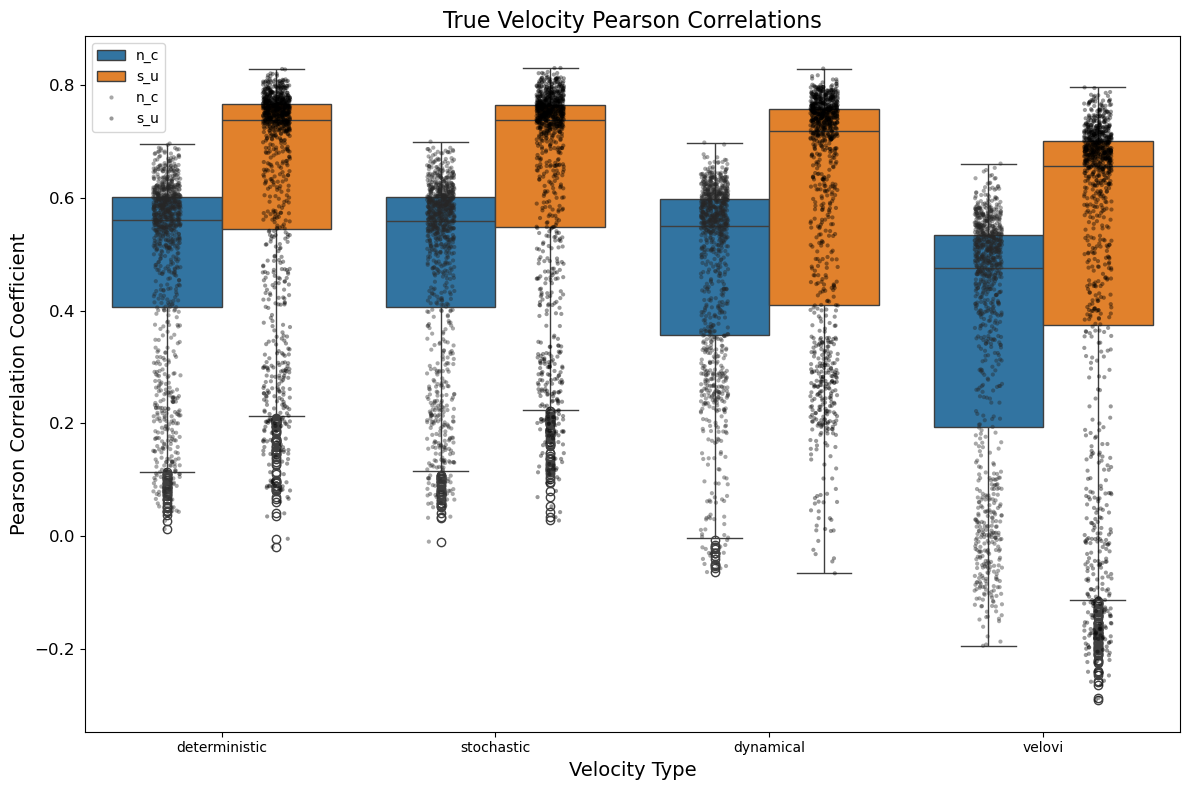

In [107]:
plot_correlation_boxplots(b)